# **EfficientNet Pre-trained Binary Model with Upsampled Transformed Input**

In this notebook we test a pre-trained EfficientNet model to predict Animal vs Non-animal. <br>
For this, transformed/pre-processed images were used and the class imbalance was fixed. <br>
The transformed images are the ones used on the `02_efficient_net_pretrained_transformations.ipynb`. <br>
The class imbalance was fixed using `label_cropper.py` and `augmenter_routine.ipynb`.

## Libraries

In [2]:
import os
os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"

In [ ]:
# Libraries
import pandas as pd

from deep.constants import ROOT, METADATA_FILE, SEEDS, SCORES
from deep.modelling.model_runs import run_binary_model
from deep.modelling.model_specifications import efficient_net_extended

2025-04-30 22:33:38.485213: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-30 22:33:38.496674: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-04-30 22:33:38.511636: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-04-30 22:33:38.515710: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-30 22:33:38.526193: I tensorflow/core/platform/cpu_feature_guar

In [4]:
# Setting options
pd.set_option('display.max_rows', None)

## Data Loading

In [5]:
# Load the metadata
data = pd.read_csv(METADATA_FILE)

# Drop unnecessary columns for this problem
data.drop(columns=['phylum', 'family'], inplace=True)

## Data Preprocessing

In [6]:
# Define seeds and path
binary_baseline_path = f"{ROOT}/models/binary_scores.json"

### Clean Images

In [6]:
# Create transformed images
notebook_path = f'"{ROOT}/notebooks/preprocess_routine/cleaner_routine.ipynb"'
%run $notebook_path

Starting preprocessing from: /home/shadybea/Documents/IMS/2024 - 2025/Projects/DeepLearning/data/raw_image_directory → /home/shadybea/Documents/IMS/2024 - 2025/Projects/DeepLearning/data/processed_image_directory
Processing: 20547029_328497.jpg
Processing: 22920623_337659.jpg
Processing: 14736025_45511271.jpg
Processing: 29580617_45514697_noanimalcrop.jpg
Processing: 3264_919473.jpg
Processing: 28475674_1057163.jpg
Processing: 14151699_45276972.jpg
Processing: 20502095_46560555.jpg
Processing: 14130546_332433.jpg
Processing: 22517382_46578204.jpg
Processing: 21943390_46560310.jpg
Processing: 28343291_45276323_noanimalcrop.jpg
Processing: 8775143_45512086.jpg
Processing: 29537897_205910.jpg
Processing: 22183999_1177988.jpg
Processing: 28675224_795885.jpg
Processing: 20258969_45512605.jpg
Processing: 21023061_46570657.jpg
Processing: 9485039_46559307.jpg
Processing: 29265023_792821.jpg
Processing: 22240813_45517756.jpg
Processing: 21062136_4472389.jpg
Processing: 22105011_1056984.jpg
Pro

### Upsample Images

In [7]:
# DISCLAIMER: Ensure you are using 'json_path = UPSAMPLE_JSONS / "is_animal_upsample_plan_20250427T092327Z.json"'

# Create upsamples images
notebook_path = f'"{ROOT}/notebooks/preprocess_routine/augmenter_routine.ipynb"'
%run $notebook_path

Failed on 28274715_45276283_noanimalcrop.jpg: [Errno 2] No such file or directory: '/home/shadybea/Documents/IMS/2024 - 2025/Projects/DeepLearning/data/processed_image_directory/28274715_45276283_noanimalcrop.jpg'
Failed on 20547029_328497_noanimalcrop.jpg: [Errno 2] No such file or directory: '/home/shadybea/Documents/IMS/2024 - 2025/Projects/DeepLearning/data/processed_image_directory/20547029_328497_noanimalcrop.jpg'
Failed on 28274715_45276283_noanimalcrop.jpg: [Errno 2] No such file or directory: '/home/shadybea/Documents/IMS/2024 - 2025/Projects/DeepLearning/data/processed_image_directory/28274715_45276283_noanimalcrop.jpg'
Failed on 20547029_328497_noanimalcrop.jpg: [Errno 2] No such file or directory: '/home/shadybea/Documents/IMS/2024 - 2025/Projects/DeepLearning/data/processed_image_directory/20547029_328497_noanimalcrop.jpg'


### Resize Images

In [8]:
# Resize images
notebook_path = f'"{ROOT}/notebooks/preprocess_routine/resize_routine.ipynb"'
%run $notebook_path

I0000 00:00:1746019999.146259   56100 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1746019999.183530   56100 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1746019999.183738   56100 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1746019999.184773   56100 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

## Data Modelling

### Raw Model

#### Binary CrossEntropy

Loaded baseline score: 0.9301187992095947
Found 15375 validated image filenames belonging to 2 classes.
Found 1439 validated image filenames belonging to 2 classes.
Found 2397 validated image filenames belonging to 2 classes.


/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/legacy/preprocessing/image.py:920: UserWarning: Found 2 invalid image filename(s) in x_col="file_path". These filename(s) will be ignored.
  warnings.warn(


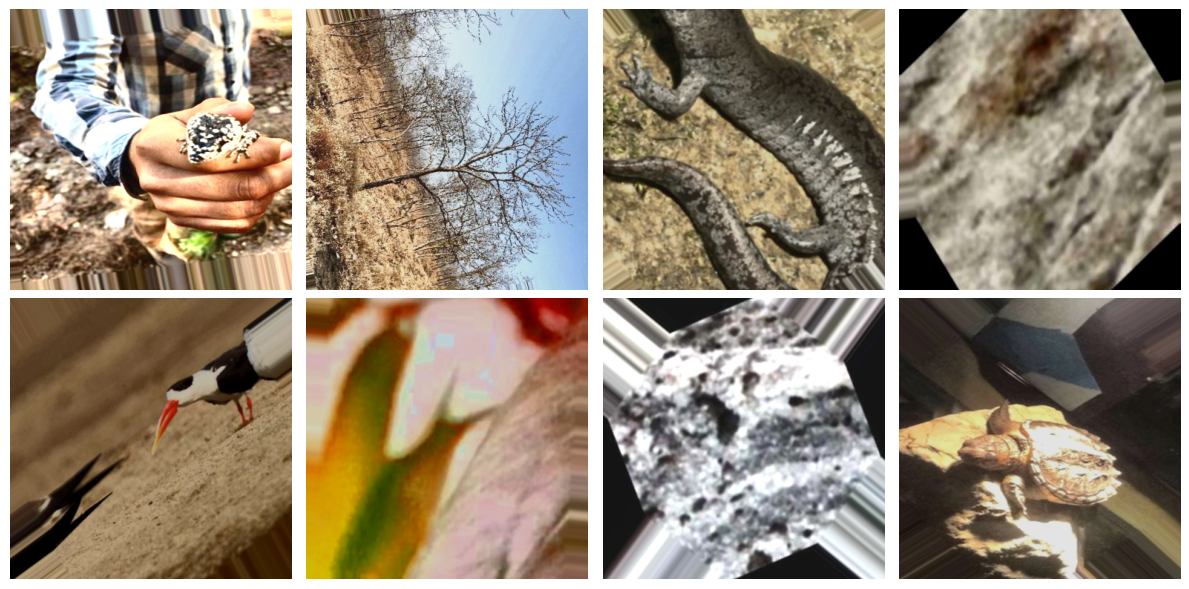

/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1746021446.131313   56424 service.cc:146] XLA service 0x765bec003ae0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1746021446.131343   56424 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce MX350, Compute Capability 6.1
2025-04-30 14:57:26.879539: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-04-30 14:57:29.479680: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 90100
2025-04-30 14:57:35.502440: E external/local_xla/xla/stream_executor/gpu/gpu_cudamallocasync_allocator.cc:310] gpu_async_0 cuMemAllocAsync failed to allocate 1437078016 bytes: CUDA error: out of memory (CUDA_ERROR_OUT_OF_MEMORY)
 Reported by CUDA: Free memory/Total memory: 249167872/2091253760
2025-04-30 14:57:35.502484: E external/local_xla/xla/stream_executor/gpu/gpu_cudamallocasync_allocator.cc

466/481 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.6115 - auc: 0.6463 - loss: 0.6639 - precision: 0.6142 - recall: 0.5952

2025-04-30 15:09:40.196380: E external/local_xla/xla/stream_executor/gpu/gpu_cudamallocasync_allocator.cc:310] gpu_async_0 cuMemAllocAsync failed to allocate 2033104384 bytes: CUDA error: out of memory (CUDA_ERROR_OUT_OF_MEMORY)
 Reported by CUDA: Free memory/Total memory: 242876416/2091253760
2025-04-30 15:09:40.196422: E external/local_xla/xla/stream_executor/gpu/gpu_cudamallocasync_allocator.cc:315] Stats: Limit:                      1806303232
InUse:                       843356964
MaxInUse:                   1953122708
NumAllocs:                       56793
MaxAllocSize:               1621712896
Reserved:                            0
PeakReserved:                        0
LargestFreeBlock:                    0

2025-04-30 15:09:40.196510: E external/local_xla/xla/stream_executor/gpu/gpu_cudamallocasync_allocator.cc:64] Histogram of current allocation: (allocation_size_in_bytes, nb_allocation_of_that_sizes), ...;
2025-04-30 15:09:40.196542: E external/local_xla/xla/stream_executor/

481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6122 - auc: 0.6472 - loss: 0.6634 - precision: 0.6150 - recall: 0.5952

2025-04-30 15:11:17.538540: E external/local_xla/xla/stream_executor/gpu/gpu_cudamallocasync_allocator.cc:310] gpu_async_0 cuMemAllocAsync failed to allocate 1411715584 bytes: CUDA error: out of memory (CUDA_ERROR_OUT_OF_MEMORY)
 Reported by CUDA: Free memory/Total memory: 236584960/2091253760
2025-04-30 15:11:17.538590: E external/local_xla/xla/stream_executor/gpu/gpu_cudamallocasync_allocator.cc:315] Stats: Limit:                      1806303232
InUse:                       625015276
MaxInUse:                   1953122708
NumAllocs:                       58343
MaxAllocSize:               1621712896
Reserved:                            0
PeakReserved:                        0
LargestFreeBlock:                    0

2025-04-30 15:11:17.538769: E external/local_xla/xla/stream_executor/gpu/gpu_cudamallocasync_allocator.cc:64] Histogram of current allocation: (allocation_size_in_bytes, nb_allocation_of_that_sizes), ...;
2025-04-30 15:11:17.538783: E external/local_xla/xla/stream_executor/

481/481 ━━━━━━━━━━━━━━━━━━━━ 877s 2s/step - accuracy: 0.6123 - auc: 0.6473 - loss: 0.6634 - precision: 0.6150 - recall: 0.5952 - val_accuracy: 0.0709 - val_auc: 0.6064 - val_loss: 1.7624 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/10
481/481 ━━━━━━━━━━━━━━━━━━━━ 766s 2s/step - accuracy: 0.6695 - auc: 0.7180 - loss: 0.6177 - precision: 0.6937 - recall: 0.5958 - val_accuracy: 0.9201 - val_auc: 0.6173 - val_loss: 0.4026 - val_precision: 0.9333 - val_recall: 0.9843 - learning_rate: 0.0010
Epoch 3/10
481/481 ━━━━━━━━━━━━━━━━━━━━ 778s 2s/step - accuracy: 0.6827 - auc: 0.7397 - loss: 0.6036 - precision: 0.7018 - recall: 0.6141 - val_accuracy: 0.0716 - val_auc: 0.6236 - val_loss: 1.1518 - val_precision: 1.0000 - val_recall: 7.4794e-04 - learning_rate: 0.0010
Epoch 4/10
481/481 ━━━━━━━━━━━━━━━━━━━━ 779s 2s/step - accuracy: 0.6863 - auc: 0.7380 - loss: 0.6031 - precision: 0.7006 - recall: 0.6180 - val_accuracy: 0.9291 - val_auc: 0.6127 - val_loss: 0.2622 

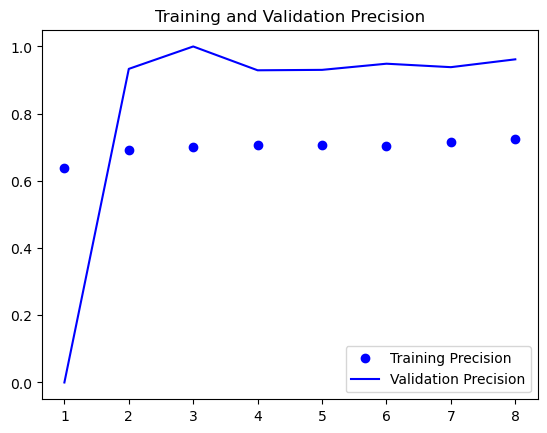

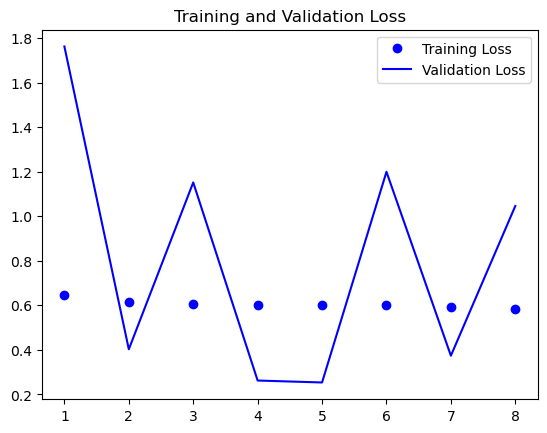

Saved current model as new baseline


In [ ]:
run_binary_model(
    file_path=binary_baseline_path
    ,data=data
    ,seed=SEEDS[0]
    ,model=efficient_net_extended(
        regularizer=False
        ,dropout=False
        ,task_type='binary'
    )
    ,loss='crossentropy'
    ,epochs=10
    ,type='upsampled'
    ,model_name='efficientnetb4'
)

#### Focal Loss

I0000 00:00:1746040344.260792    4373 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1746040344.425132    4373 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1746040344.425420    4373 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1746040344.426645    4373 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

Loaded baseline score: 0.9304105639457703
Found 15375 validated image filenames belonging to 2 classes.
Found 1439 validated image filenames belonging to 2 classes.
Found 2397 validated image filenames belonging to 2 classes.


/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/legacy/preprocessing/image.py:920: UserWarning: Found 2 invalid image filename(s) in x_col="file_path". These filename(s) will be ignored.
  warnings.warn(


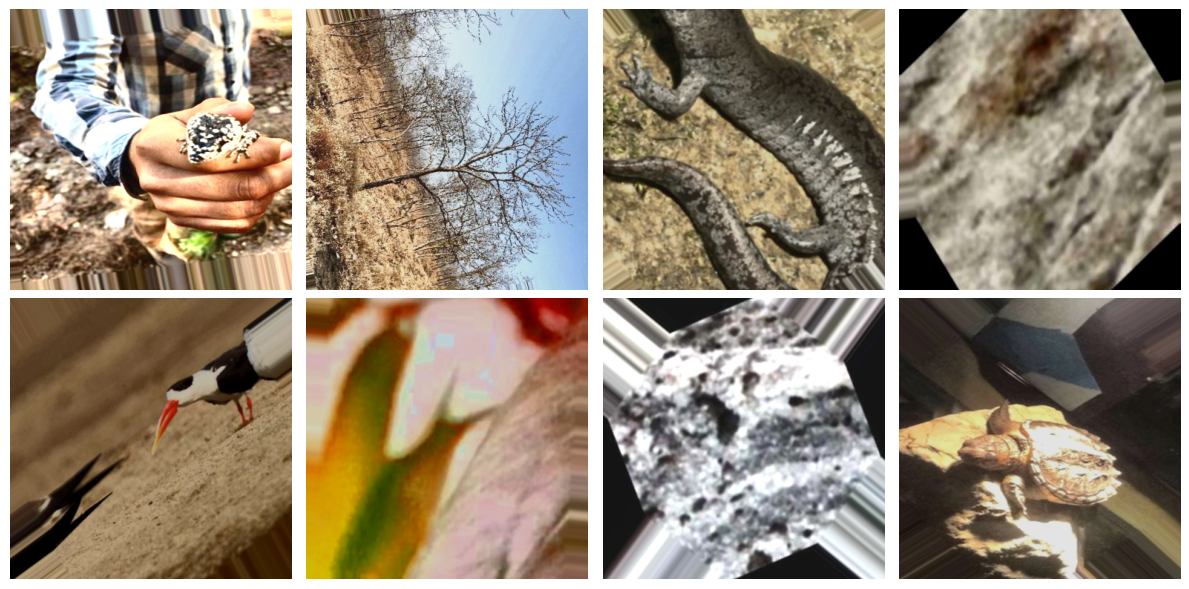

/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1746040365.224779    4602 service.cc:146] XLA service 0x7c74cc002b90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1746040365.224801    4602 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce MX350, Compute Capability 6.1
2025-04-30 20:12:45.887903: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-04-30 20:12:48.057654: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 90100
2025-04-30 20:12:53.736000: W external/local_tsl/tsl/framework/bfc_allocator.cc:291] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.34GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-04-30 20:12:56.872957: E external/local_xla/xla/service/slow_operation_alarm.cc:65] 

248/481 ━━━━━━━━━━━━━━━━━━━━ 4:20 1s/step - accuracy: 0.5109 - auc: 0.5053 - loss: 0.0241 - precision: 0.4985 - recall: 0.1134

2025-04-30 20:18:14.282017: W external/local_tsl/tsl/framework/bfc_allocator.cc:291] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.89GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5108 - auc: 0.5018 - loss: 0.0207 - precision: 0.5021 - recall: 0.1022

2025-04-30 20:24:09.173073: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng42{k2=2,k4=2,k5=0,k6=0,k7=0} for conv (f32[31,24,190,190]{3,2,1,0}, u8[0]{0}) custom-call(f32[31,24,190,190]{3,2,1,0}, f32[24,1,3,3]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, feature_group_count=24, custom_call_target="__cudnn$convForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false} is taking a while...
2025-04-30 20:24:09.318768: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 1.145813105s
Trying algorithm eng42{k2=2,k4=2,k5=0,k6=0,k7=0} for conv (f32[31,24,190,190]{3,2,1,0}, u8[0]{0}) custom-call(f32[31,24,190,190]{3,2,1,0}, f32[24,1,3,3]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, feature_group_count=24, custom_ca

481/481 ━━━━━━━━━━━━━━━━━━━━ 722s 1s/step - accuracy: 0.5108 - auc: 0.5018 - loss: 0.0207 - precision: 0.5021 - recall: 0.1022 - val_accuracy: 0.0709 - val_auc: 0.4951 - val_loss: 0.0205 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/10
481/481 ━━━━━━━━━━━━━━━━━━━━ 636s 1s/step - accuracy: 0.5100 - auc: 0.5040 - loss: 0.0156 - precision: 0.4898 - recall: 0.0527 - val_accuracy: 0.0709 - val_auc: 0.5137 - val_loss: 0.0138 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/10
481/481 ━━━━━━━━━━━━━━━━━━━━ 667s 1s/step - accuracy: 0.5108 - auc: 0.4906 - loss: 0.0155 - precision: 0.5167 - recall: 0.0325 - val_accuracy: 0.0709 - val_auc: 0.4466 - val_loss: 0.0133 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 4/10
481/481 ━━━━━━━━━━━━━━━━━━━━ 690s 1s/step - accuracy: 0.5051 - auc: 0.5082 - loss: 0.0154 - precision: 0.5078 - recall: 0.0257 - val_accuracy: 0.0709 - val_auc: 0.4441 - val_l

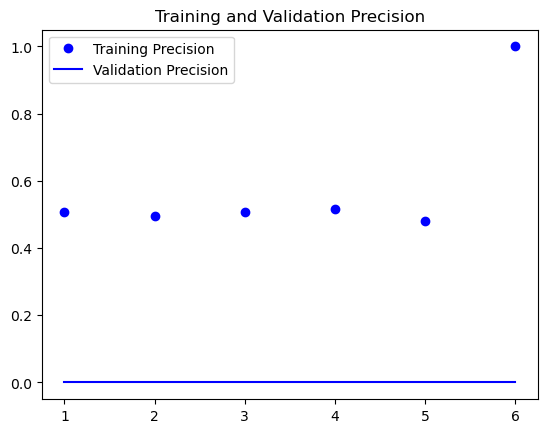

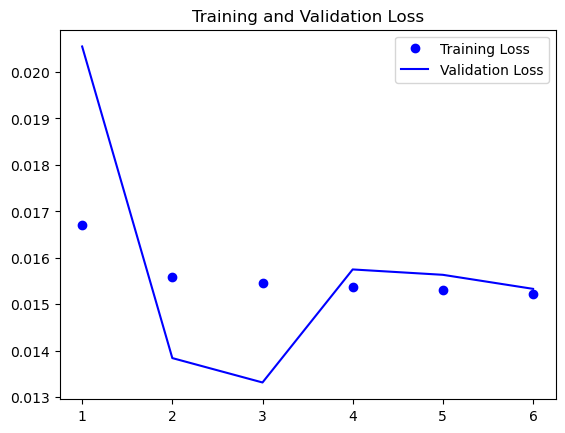

Current model not better than baseline


In [ ]:
run_binary_model(
    file_path=binary_baseline_path
    ,data=data
    ,seed=SEEDS[0]
    ,model=efficient_net_extended(
        regularizer=False
        ,dropout=False
        ,task_type='binary'
    )
    ,loss='focal'
    ,epochs=10
    ,type='upsampled'
    ,model_name='efficientnetb4'
)

This model using the transformed and upsampled images proved to be underfitting the training data, although using the binary crossentropy yielded better results. <br>
We will, however, test if adding regularization and/or the dropout layer will improve the underfitting and the model performance vis the baseline.

### Model with Regularization

In this section we add L2 regularization to our model and test if it improves the model

Loaded baseline score: 0.9304105639457703
Found 15375 validated image filenames belonging to 2 classes.
Found 1439 validated image filenames belonging to 2 classes.
Found 2397 validated image filenames belonging to 2 classes.


/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/legacy/preprocessing/image.py:920: UserWarning: Found 2 invalid image filename(s) in x_col="file_path". These filename(s) will be ignored.
  warnings.warn(


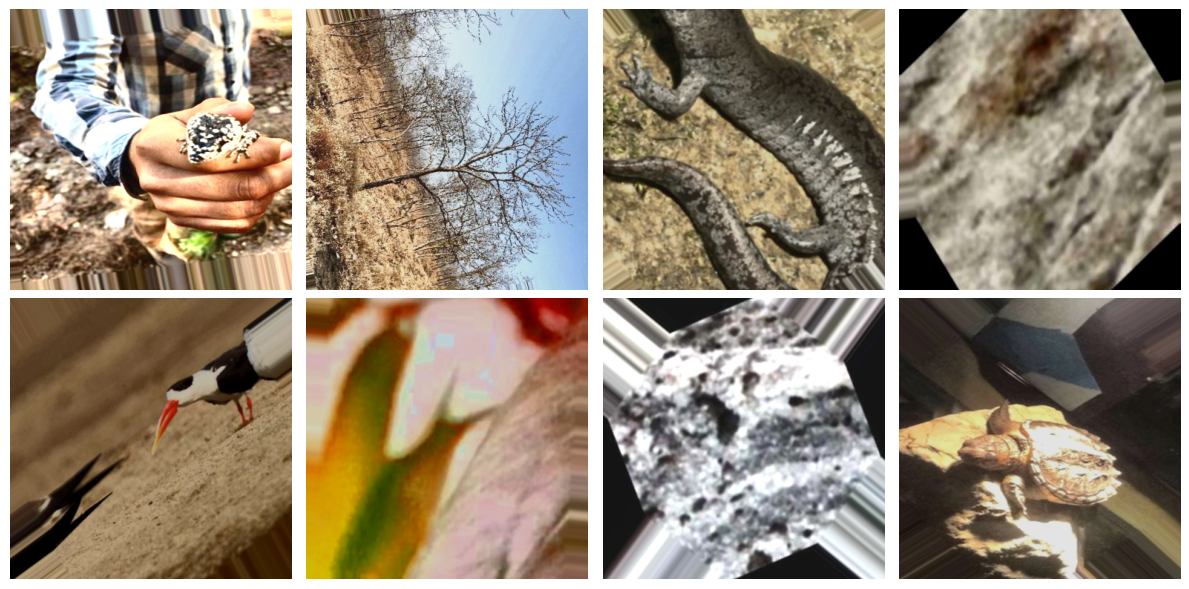

/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
481/481 ━━━━━━━━━━━━━━━━━━━━ 693s 1s/step - accuracy: 0.6031 - auc_1: 0.6322 - loss: 0.7872 - precision: 0.6076 - recall: 0.5240 - val_accuracy: 0.9284 - val_auc_1: 0.6101 - val_loss: 0.4010 - val_precision: 0.9315 - val_recall: 0.9963 - learning_rate: 0.0010
Epoch 2/10
481/481 ━━━━━━━━━━━━━━━━━━━━ 687s 1s/step - accuracy: 0.6573 - auc_1: 0.7066 - loss: 0.6286 - precision: 0.6736 - recall: 0.5863 - val_accuracy: 0.9291 - val_auc_1: 0.6164 - val_loss: 0.2587 - val_precision: 0.9291 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/10
481/481 ━━━━━━━━━━━━━━━━━━━━ 705s 1s/step - accuracy: 0.5849 - auc_1: 0.6278 - loss: 0.6602 - precision: 0.5962 - recall: 0.4863 - val_accuracy: 0.0709 - val_auc_1: 0.5000 - val_loss: 0.8660 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 4/10
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5136 - auc_1: 0.5151 - loss: 0.6922 - precision: 0.4848 - recall: 0.3493
Epoch 4: ReduceLROnPlateau reducing learn

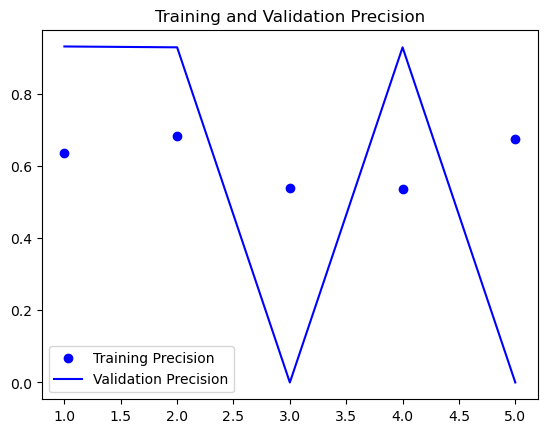

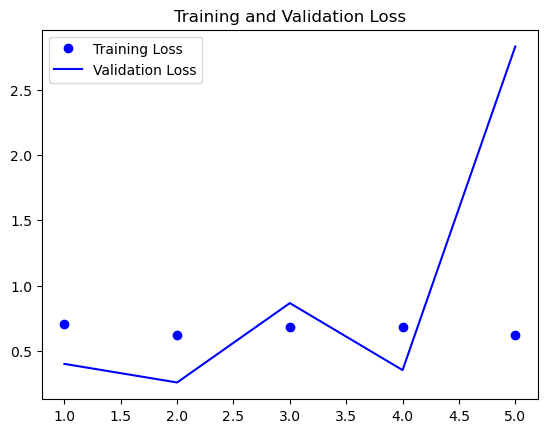

Current model not better than baseline


In [ ]:
run_binary_model(
    file_path=binary_baseline_path
    ,data=data
    ,seed=SEEDS[0]
    ,model=efficient_net_extended(
        regularizer=True
        ,dropout=False
        ,task_type='binary'
    )
    ,loss='crossentropy'
    ,epochs=10
    ,type='upsampled'
    ,model_name='efficientnetb4'
)

Regularization did not improve the model.

### Model with Dropout

In this section we add a dropout layer to the model and test if it improves the results.

I0000 00:00:1746048826.878341   14009 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1746048826.918507   14009 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1746048826.918802   14009 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1746048826.920227   14009 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

Loaded baseline score: 0.9304105639457703
Found 15375 validated image filenames belonging to 2 classes.
Found 1439 validated image filenames belonging to 2 classes.
Found 2397 validated image filenames belonging to 2 classes.


/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/legacy/preprocessing/image.py:920: UserWarning: Found 2 invalid image filename(s) in x_col="file_path". These filename(s) will be ignored.
  warnings.warn(


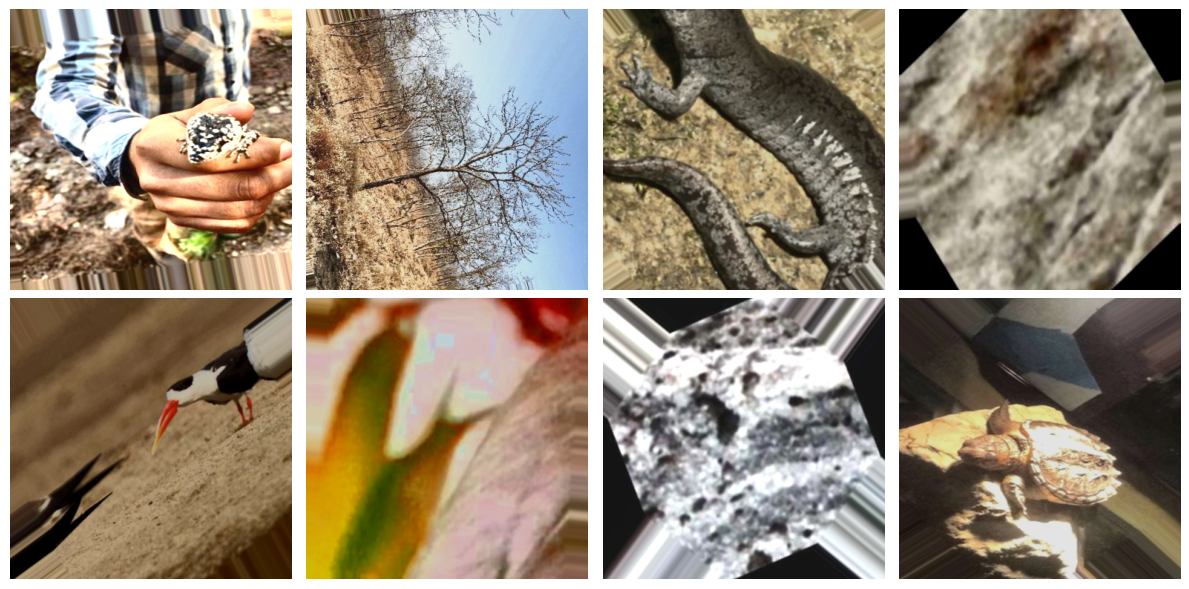

/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1746048849.057330   14137 service.cc:146] XLA service 0x7d1094002f80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1746048849.057353   14137 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce MX350, Compute Capability 6.1
2025-04-30 22:34:09.731499: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-04-30 22:34:12.078604: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 90100
2025-04-30 22:34:17.797786: E external/local_xla/xla/stream_executor/gpu/gpu_cudamallocasync_allocator.cc:310] gpu_async_0 cuMemAllocAsync failed to allocate 1437078016 bytes: CUDA error: out of memory (CUDA_ERROR_OUT_OF_MEMORY)
 Reported by CUDA: Free memory/Total memory: 249167872/2091253760
2025-04-30 22:34:17.797818: E external/local_xla/xla/stream_executor/gpu/gpu_cudamallocasync_allocator.cc

451/481 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.5568 - auc: 0.5754 - loss: 0.6936 - precision: 0.5530 - recall: 0.5103

2025-04-30 22:44:54.152626: E external/local_xla/xla/stream_executor/gpu/gpu_cudamallocasync_allocator.cc:310] gpu_async_0 cuMemAllocAsync failed to allocate 2033104384 bytes: CUDA error: out of memory (CUDA_ERROR_OUT_OF_MEMORY)
 Reported by CUDA: Free memory/Total memory: 242876416/2091253760
2025-04-30 22:44:54.152664: E external/local_xla/xla/stream_executor/gpu/gpu_cudamallocasync_allocator.cc:315] Stats: Limit:                      1806303232
InUse:                       843356680
MaxInUse:                   1933780836
NumAllocs:                       11025
MaxAllocSize:               1621712896
Reserved:                            0
PeakReserved:                        0
LargestFreeBlock:                    0

2025-04-30 22:44:54.152741: E external/local_xla/xla/stream_executor/gpu/gpu_cudamallocasync_allocator.cc:64] Histogram of current allocation: (allocation_size_in_bytes, nb_allocation_of_that_sizes), ...;
2025-04-30 22:44:54.152747: E external/local_xla/xla/stream_executor/

481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5568 - auc: 0.5758 - loss: 0.6932 - precision: 0.5534 - recall: 0.5080

2025-04-30 22:46:45.614780: E external/local_xla/xla/stream_executor/gpu/gpu_cudamallocasync_allocator.cc:310] gpu_async_0 cuMemAllocAsync failed to allocate 1411715584 bytes: CUDA error: out of memory (CUDA_ERROR_OUT_OF_MEMORY)
 Reported by CUDA: Free memory/Total memory: 236584960/2091253760
2025-04-30 22:46:45.614822: E external/local_xla/xla/stream_executor/gpu/gpu_cudamallocasync_allocator.cc:315] Stats: Limit:                      1806303232
InUse:                       625015292
MaxInUse:                   1933780836
NumAllocs:                       12815
MaxAllocSize:               1621712896
Reserved:                            0
PeakReserved:                        0
LargestFreeBlock:                    0

2025-04-30 22:46:45.614922: E external/local_xla/xla/stream_executor/gpu/gpu_cudamallocasync_allocator.cc:64] Histogram of current allocation: (allocation_size_in_bytes, nb_allocation_of_that_sizes), ...;
2025-04-30 22:46:45.614929: E external/local_xla/xla/stream_executor/

481/481 ━━━━━━━━━━━━━━━━━━━━ 800s 2s/step - accuracy: 0.5568 - auc: 0.5758 - loss: 0.6932 - precision: 0.5534 - recall: 0.5079 - val_accuracy: 0.0709 - val_auc: 0.4679 - val_loss: 0.9581 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/10
481/481 ━━━━━━━━━━━━━━━━━━━━ 679s 1s/step - accuracy: 0.5354 - auc: 0.5504 - loss: 0.6875 - precision: 0.5340 - recall: 0.4893 - val_accuracy: 0.0709 - val_auc: 0.6098 - val_loss: 1.3086 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/10
481/481 ━━━━━━━━━━━━━━━━━━━━ 686s 1s/step - accuracy: 0.5793 - auc: 0.6192 - loss: 0.6688 - precision: 0.6008 - recall: 0.4513 - val_accuracy: 0.8937 - val_auc: 0.6074 - val_loss: 0.5006 - val_precision: 0.9379 - val_recall: 0.9484 - learning_rate: 0.0010
Epoch 4/10
481/481 ━━━━━━━━━━━━━━━━━━━━ 681s 1s/step - accuracy: 0.6150 - auc: 0.6668 - loss: 0.6485 - precision: 0.6448 - recall: 0.4853 - val_accuracy: 0.1341 - val_auc: 0.6125 - val_loss: 0.9

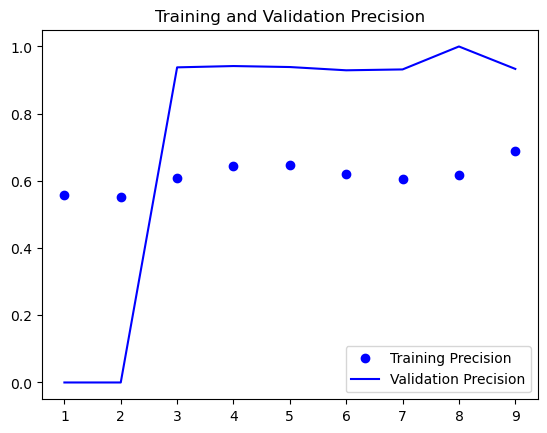

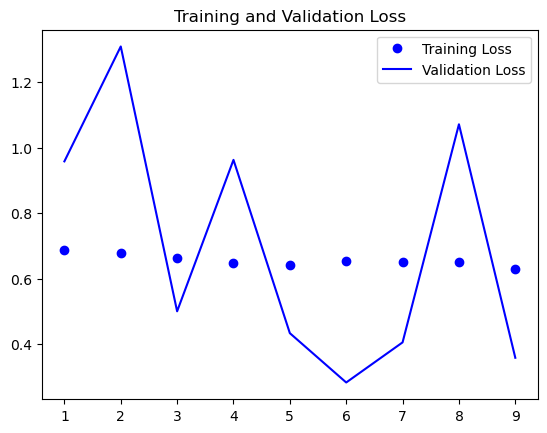

Current model not better than baseline


In [ ]:
run_binary_model(
    file_path=binary_baseline_path
    ,data=data
    ,seed=SEEDS[0]
    ,model=efficient_net_extended(
        regularizer=False
        ,dropout=True
        ,task_type='binary'
    )
    ,loss='crossentropy'
    ,epochs=10
    ,type='upsampled'
    ,model_name='efficientnetb4'
)

The dropout layer did not improve the model.

Now, we will attempt to fix the class imbalance based on the transformed images and recheck the model.